# **Data Cleaning**

In [ ]:
import requests
import pandas as pd
marketing_df = pd.read_csv('marketing_campaign_data.csv')
marketing_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [ ]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

In [ ]:
from datetime import datetime

current_year = datetime.now().year
marketing_df['Age'] = current_year - marketing_df['Year_Birth']
marketing_df.insert(1, 'Age', marketing_df.pop('Age'))
marketing_df.head()

,ID,Age,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,41,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,51,1975,Master,Single,1730.0,1,1,2013-04-10,96,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,48,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,50,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,45,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,...,3,6,0,0,0,0,0,0,0,Canada


In [ ]:
from datetime import datetime

marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'])
marketing_df['Tenure_Days'] = (datetime.now() - marketing_df['Dt_Customer']).dt.days
marketing_df['Tenure_Months'] = (marketing_df['Tenure_Days'] / 30.44).astype(int)
marketing_df.insert(2, 'Tenure_Months', marketing_df.pop('Tenure_Months'))
marketing_df.head()

,ID,Age,Tenure_Months,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Tenure_Days
0,342199,41,159,1985,Graduation,Together,59011.7,1,0,2012-11-17,...,4,0,0,0,0,0,0,0,Spain,4869
1,8075450,51,155,1975,Master,Single,1730.0,1,1,2013-04-10,...,3,0,0,0,0,0,0,0,Spain,4725
2,13664263,48,146,1978,Graduation,Married,98584.6,0,0,2014-01-11,...,3,0,0,0,0,0,0,0,Australia,4449
3,16164787,50,140,1976,Graduation,Married,74031.5,1,0,2014-06-18,...,4,0,0,0,0,0,0,0,Spain,4291
4,15815139,45,141,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,...,6,0,0,0,0,0,0,0,Canada,4320


In [ ]:
marketing_df['Children'] = marketing_df['Kidhome'] + marketing_df['Teenhome']
marketing_df.insert(6, 'Children', marketing_df.pop('Children'))
marketing_df.head()

,ID,Age,Tenure_Months,Year_Birth,Education,Marital_Status,Children,Income,Kidhome,Teenhome,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Tenure_Days
0,342199,41,159,1985,Graduation,Together,1,59011.7,1,0,...,4,0,0,0,0,0,0,0,Spain,4869
1,8075450,51,155,1975,Master,Single,2,1730.0,1,1,...,3,0,0,0,0,0,0,0,Spain,4725
2,13664263,48,146,1978,Graduation,Married,0,98584.6,0,0,...,3,0,0,0,0,0,0,0,Australia,4449
3,16164787,50,140,1976,Graduation,Married,1,74031.5,1,0,...,4,0,0,0,0,0,0,0,Spain,4291
4,15815139,45,141,1981,Graduation,Divorced,2,52784.2,1,1,...,6,0,0,0,0,0,0,0,Canada,4320


In [ ]:
marketing_df = marketing_df.rename(columns = {"MntWines" : "Wine", "MntFruits" : "Fruits", "Dt_Customer" : "Customer_Since", "MntMeatProducts" : "Meat_Prod", "MntFishProducts" : "Fish_Prod", "MntSweetProducts" : "Sweet_Prod", "MntGoldProds" : "Gold_Prod", "NumDealsPurchases" : "Deal_Purchase", "NumWebPurchases" : "Web_Purchase", "NumCatalogPurchases" : "Catalog_Purchase", "NumStorePurchases" : "Store_Purchase","NumWebVisitsMonth" : "Web_Visits_Month"})
marketing_df.head()

,ID,Age,Tenure_Months,Year_Birth,Education,Marital_Status,Children,Income,Kidhome,Teenhome,...,Web_Visits_Month,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Tenure_Days
0,342199,41,159,1985,Graduation,Together,1,59011.7,1,0,...,4,0,0,0,0,0,0,0,Spain,4869
1,8075450,51,155,1975,Master,Single,2,1730.0,1,1,...,3,0,0,0,0,0,0,0,Spain,4725
2,13664263,48,146,1978,Graduation,Married,0,98584.6,0,0,...,3,0,0,0,0,0,0,0,Australia,4449
3,16164787,50,140,1976,Graduation,Married,1,74031.5,1,0,...,4,0,0,0,0,0,0,0,Spain,4291
4,15815139,45,141,1981,Graduation,Divorced,2,52784.2,1,1,...,6,0,0,0,0,0,0,0,Canada,4320


In [ ]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                56000 non-null  int64         
 1   Age               56000 non-null  int64         
 2   Tenure_Months     56000 non-null  int64         
 3   Year_Birth        56000 non-null  int64         
 4   Education         56000 non-null  object        
 5   Marital_Status    56000 non-null  object        
 6   Children          56000 non-null  int64         
 7   Income            56000 non-null  float64       
 8   Kidhome           56000 non-null  int64         
 9   Teenhome          56000 non-null  int64         
 10  Customer_Since    56000 non-null  datetime64[ns]
 11  Recency           56000 non-null  int64         
 12  Wine              56000 non-null  int64         
 13  Fruits            56000 non-null  int64         
 14  Meat_Prod         5600

In [ ]:
marketing_df['Total_Spends'] = marketing_df["Wine"] + marketing_df["Fruits"] + marketing_df["Meat_Prod"] + marketing_df["Fish_Prod"] + marketing_df["Sweet_Prod"] + marketing_df["Gold_Prod"]
marketing_df.insert(8, "Total_Spends", marketing_df.pop("Total_Spends"))
marketing_df.head()

,ID,Age,Tenure_Months,Year_Birth,Education,Marital_Status,Children,Income,Total_Spends,Kidhome,...,Web_Visits_Month,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Tenure_Days
0,342199,41,159,1985,Graduation,Together,1,59011.7,69,1,...,4,0,0,0,0,0,0,0,Spain,4869
1,8075450,51,155,1975,Master,Single,2,1730.0,39,1,...,3,0,0,0,0,0,0,0,Spain,4725
2,13664263,48,146,1978,Graduation,Married,0,98584.6,1512,0,...,3,0,0,0,0,0,0,0,Australia,4449
3,16164787,50,140,1976,Graduation,Married,1,74031.5,478,1,...,4,0,0,0,0,0,0,0,Spain,4291
4,15815139,45,141,1981,Graduation,Divorced,2,52784.2,330,1,...,6,0,0,0,0,0,0,0,Canada,4320


In [ ]:
marketing_df["Total_Num_Purchases"] = marketing_df["Deal_Purchase"] + marketing_df["Web_Purchase"] + marketing_df["Catalog_Purchase"] + marketing_df["Store_Purchase"]
marketing_df.insert(9, "Total_Num_Purchases", marketing_df.pop("Total_Num_Purchases"))
marketing_df.head()

,ID,Age,Tenure_Months,Year_Birth,Education,Marital_Status,Children,Income,Total_Spends,Total_Num_Purchases,...,Web_Visits_Month,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Tenure_Days
0,342199,41,159,1985,Graduation,Together,1,59011.7,69,13,...,4,0,0,0,0,0,0,0,Spain,4869
1,8075450,51,155,1975,Master,Single,2,1730.0,39,4,...,3,0,0,0,0,0,0,0,Spain,4725
2,13664263,48,146,1978,Graduation,Married,0,98584.6,1512,12,...,3,0,0,0,0,0,0,0,Australia,4449
3,16164787,50,140,1976,Graduation,Married,1,74031.5,478,16,...,4,0,0,0,0,0,0,0,Spain,4291
4,15815139,45,141,1981,Graduation,Divorced,2,52784.2,330,9,...,6,0,0,0,0,0,0,0,Canada,4320


In [ ]:
marketing_df.drop(columns = ["Year_Birth", "Teenhome", "Kidhome","Tenure_Days"], inplace = True)
marketing_df.head()

,ID,Age,Tenure_Months,Education,Marital_Status,Children,Income,Total_Spends,Total_Num_Purchases,Customer_Since,...,Store_Purchase,Web_Visits_Month,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,41,159,Graduation,Together,1,59011.7,69,13,2012-11-17,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,51,155,Master,Single,2,1730.0,39,4,2013-04-10,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,48,146,Graduation,Married,0,98584.6,1512,12,2014-01-11,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,50,140,Graduation,Married,1,74031.5,478,16,2014-06-18,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,45,141,Graduation,Divorced,2,52784.2,330,9,2014-05-20,...,3,6,0,0,0,0,0,0,0,Canada


In [ ]:
marketing_df["Total_Campaigns"] = marketing_df["AcceptedCmp1"] + marketing_df["AcceptedCmp2"] + marketing_df["AcceptedCmp3"] + marketing_df["AcceptedCmp4"] + marketing_df["AcceptedCmp5"]
marketing_df.insert(10, "Total_Campaigns", marketing_df.pop("Total_Campaigns"))
marketing_df.drop(columns = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"], inplace = True)
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   56000 non-null  int64         
 1   Age                  56000 non-null  int64         
 2   Tenure_Months        56000 non-null  int64         
 3   Education            56000 non-null  object        
 4   Marital_Status       56000 non-null  object        
 5   Children             56000 non-null  int64         
 6   Income               56000 non-null  float64       
 7   Total_Spends         56000 non-null  int64         
 8   Total_Num_Purchases  56000 non-null  int64         
 9   Customer_Since       56000 non-null  datetime64[ns]
 10  Total_Campaigns      56000 non-null  int64         
 11  Recency              56000 non-null  int64         
 12  Wine                 56000 non-null  int64         
 13  Fruits               56000 non-

#** Outlier Treatment**

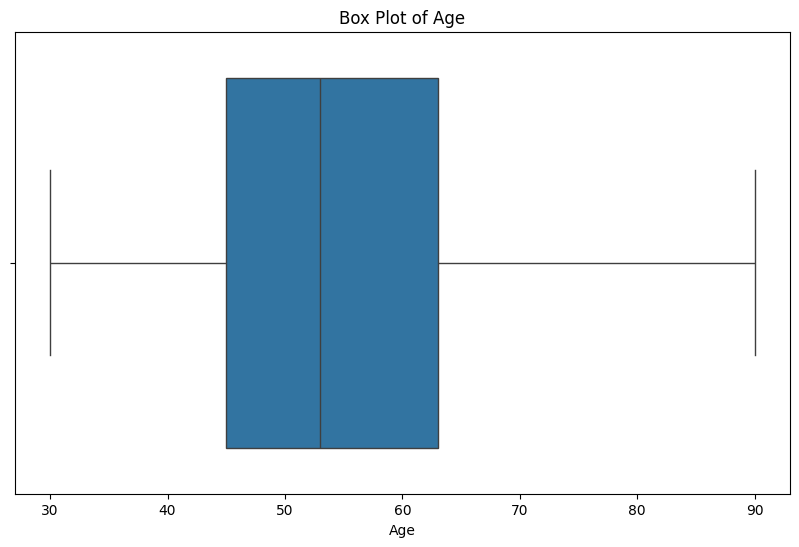

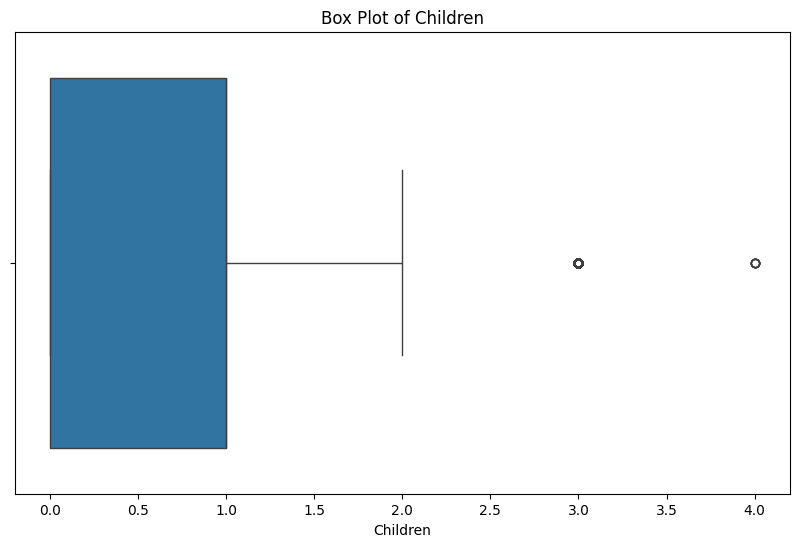

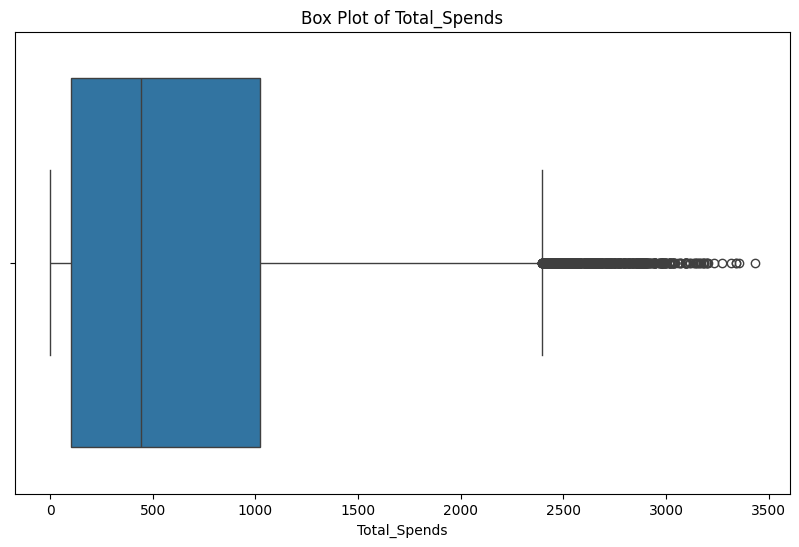

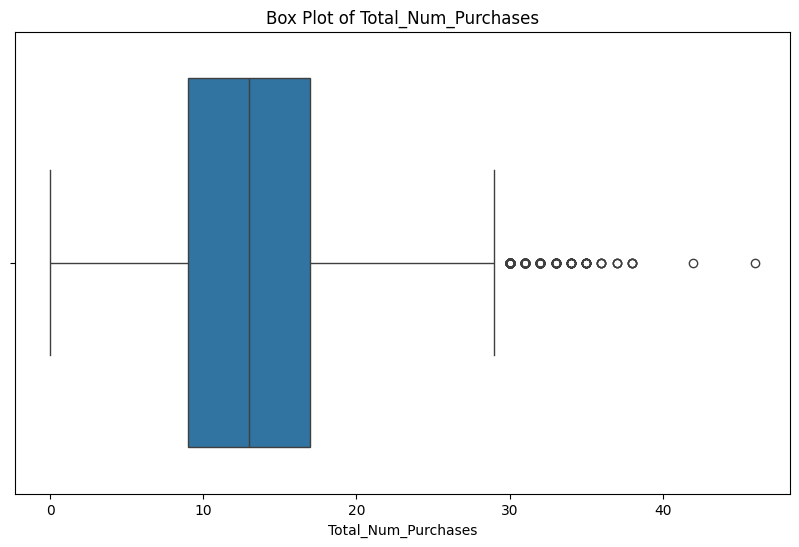

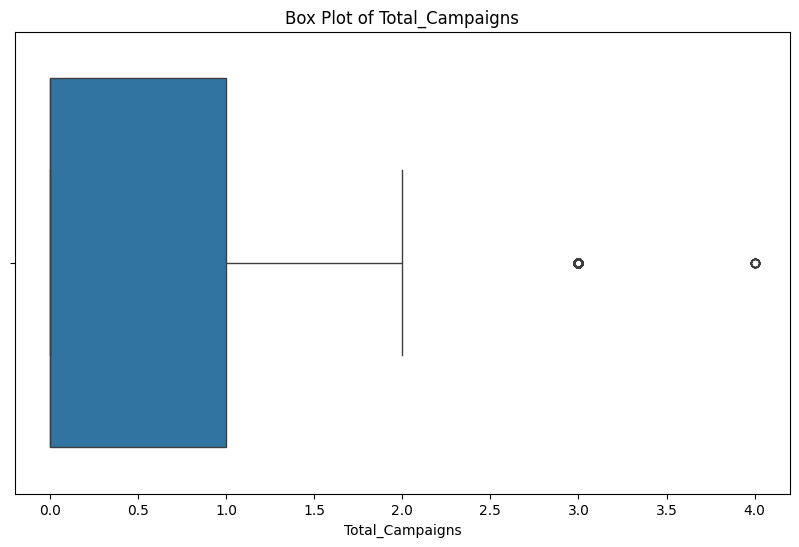

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_outliers = ["Age", "Children", "Total_Spends", "Total_Num_Purchases", "Total_Campaigns"]

for col in numerical_cols_for_outliers:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=marketing_df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [ ]:
print("Before removing outliers:")
print(marketing_df.describe())

def replace_outliers_with_median(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[column] = df[column].apply(lambda x: Q3 if x > upper_bound else x)
  df[column] = df[column].apply(lambda x: Q1 if x < lower_bound else x)
  return df

for col in numerical_cols_for_outliers:
  marketing_df = replace_outliers_with_median(marketing_df, col)

print("After removing outliers:")
print(marketing_df.describe())


Before removing outliers:
                 ID           Age  Tenure_Months      Children         Income  \
count  5.600000e+04  56000.000000   56000.000000  56000.000000   56000.000000   
mean   8.389352e+06     54.333304     150.529911      0.902054   57252.189521   
min    3.600000e+01     30.000000     140.000000      0.000000    1730.000000   
25%    4.187372e+06     45.000000     144.000000      0.000000   28252.025000   
50%    8.383784e+06     53.000000     150.000000      1.000000   58838.550000   
75%    1.258576e+07     63.000000     157.000000      1.000000   86930.650000   
max    1.677716e+07     90.000000     163.000000      4.000000  258027.500000   
std    4.844638e+06     12.211066       7.258481      0.739888   34307.247999   

       Total_Spends  Total_Num_Purchases                 Customer_Since  \
count  56000.000000         56000.000000                          56000   
mean     640.334571            13.238018  2013-08-15 07:30:18.514285568   
min        0.000000

# **Saving File**

In [ ]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   56000 non-null  int64         
 1   Age                  56000 non-null  int64         
 2   Tenure_Months        56000 non-null  int64         
 3   Education            56000 non-null  object        
 4   Marital_Status       56000 non-null  object        
 5   Children             56000 non-null  float64       
 6   Income               56000 non-null  float64       
 7   Total_Spends         56000 non-null  float64       
 8   Total_Num_Purchases  56000 non-null  float64       
 9   Customer_Since       56000 non-null  datetime64[ns]
 10  Total_Campaigns      56000 non-null  float64       
 11  Recency              56000 non-null  int64         
 12  Wine                 56000 non-null  int64         
 13  Fruits               56000 non-

In [ ]:
marketing_df['Customer_Type'] = marketing_df['Children'].apply(lambda x: 'Family Customer' if x > 0 else 'Other')

display(marketing_df[['Children', 'Customer_Type']].head())

,Children,Customer_Type
0,1.0,Family Customer
1,2.0,Family Customer
2,0.0,Other
3,1.0,Family Customer
4,2.0,Family Customer


In [ ]:
bins = [-1, 350, 950, float('inf')]
labels = ['low spender', 'High spender', 'very high spender']

marketing_df['Spending_Type'] = pd.cut(marketing_df['Total_Spends'], bins=bins, labels=labels, right=True)

display(marketing_df[['Total_Spends', 'Spending_Type']].head())

,Total_Spends,Spending_Type
0,69.0,low spender
1,39.0,low spender
2,1512.0,very high spender
3,478.0,High spender
4,330.0,low spender


In [ ]:
import pandas as pd

marketing_df = pd.read_csv('marketing_data.csv')

bins = [0, 39, 49, 59, 69, 79, 89, float('inf')]
labels = ['30s', '40s', '50s', '60s', '70s', '80s', '90s']

marketing_df['Age_Segment'] = pd.cut(marketing_df['Age'], bins=bins, labels=labels, right=True)

display(marketing_df[['Age', 'Age_Segment']].head())

,Age,Age_Segment
0,41,40s
1,51,50s
2,48,40s
3,50,50s
4,45,40s


In [ ]:
bins = [-1, 3, 7, float('inf')]
labels = ['low', 'medium', 'high']

marketing_df['web_engagement'] = pd.cut(marketing_df['Web_Visits_Month'], bins=bins, labels=labels, right=True)

display(marketing_df[['Web_Visits_Month', 'web_engagement']].head())

,Web_Visits_Month,web_engagement
0,4,medium
1,3,low
2,3,low
3,4,medium
4,6,medium


In [ ]:
marketing_df.to_csv('cleaned_marketing_data.csv', index=False)
print('Data Saved')

Data Saved


# **SQL Queries**

In [ ]:
import pandas as pd
import sqlite3

df_db = pd.read_csv('cleaned_marketing_data.csv')
conn = sqlite3.connect('marketing_data.db')
df_db.to_sql('marketing_data', conn, if_exists='replace', index=False)
conn.close()
print("Data base created")

Data base created


**High Income Segment**

In [ ]:
import sqlite3
import pandas as pd
from tabulate import tabulate

conn = sqlite3.connect('marketing_data.db')

selected_columns = ['ID', 'Age', 'Income', 'Customer_Type', 'Spending_Type', 'Total_Spends']

sql_query_selected = f"SELECT {', '.join(selected_columns)} FROM marketing_data WHERE Income > 60000"

df_selected = pd.read_sql_query(sql_query_selected, conn)
conn.close()

print('Customers with High Income')
print(tabulate(df_selected.head(20), headers='keys', tablefmt='psql'))

Customers with High Income
+----+----------+-------+----------+-----------------+-------------------+----------------+
|    |       ID |   Age |   Income | Customer_Type   | Spending_Type     |   Total_Spends |
|----+----------+-------+----------+-----------------+-------------------+----------------|
|  0 | 13664263 |    48 |  98584.6 | Other           | very high spender |           1512 |
|  1 | 16164787 |    50 |  74031.5 | Family Customer | High spender      |            478 |
|  2 |  2330269 |    66 | 111080   | Other           | High spender      |            843 |
|  3 | 13223357 |    62 |  67793.7 | Family Customer | low spender       |             91 |
|  4 |   923176 |    61 | 104661   | Family Customer | very high spender |           2109 |
|  5 |  9974730 |    74 | 105437   | Other           | very high spender |           1415 |
|  6 | 13780787 |    86 |  69746.9 | Family Customer | low spender       |            108 |
|  7 |  2275327 |    60 | 103586   | Other           

**Income Vs Spends**

In [ ]:
import sqlite3
import pandas as pd
from tabulate import tabulate

conn = sqlite3.connect('marketing_data.db')
selected_columns = ['ID', 'Income', 'Total_Spends', 'Total_Num_Purchases', 'Spending_Type',
'CAST(Total_Spends AS REAL) / Income AS Spending_Ratio']

sql_query_selected = f"SELECT {', '.join(selected_columns)} FROM marketing_data WHERE CAST(Total_Spends AS REAL) / Income > 0.5"

df_selected = pd.read_sql_query(sql_query_selected, conn)
conn.close()

print('Customers with Spending Ratio')
print(tabulate(df_selected.head(20), headers='keys', tablefmt='grid'))

Customers with Spending Ratio
+----+----------+----------+----------------+-----------------------+-------------------+------------------+
|    |       ID |   Income |   Total_Spends |   Total_Num_Purchases | Spending_Type     |   Spending_Ratio |
+====+==========+==========+================+=======================+===================+==================+
|  0 | 13536032 |   1730   |            940 |                     6 | High spender      |         0.543353 |
+----+----------+----------+----------------+-----------------------+-------------------+------------------+
|  1 | 14907319 |   1730   |            923 |                     7 | High spender      |         0.533526 |
+----+----------+----------+----------------+-----------------------+-------------------+------------------+
|  2 |  2609332 |   1730   |           1391 |                    20 | very high spender |         0.804046 |
+----+----------+----------+----------------+-----------------------+-------------------+---------

**Purchase Type Count**

In [ ]:
import sqlite3
import pandas as pd
from tabulate import tabulate


conn = sqlite3.connect('marketing_data.db')

purchase_cols = ['Deal_Purchase', 'Web_Purchase', 'Store_Purchase', 'Catalog_Purchase']

sql_query = f"SELECT {', '.join(purchase_cols)} FROM marketing_data"

purchase_types_df = pd.read_sql_query(sql_query, conn)

total_purchase_counts = purchase_types_df.sum()

conn.close()

print('Total counts for each purchase type:')
print(tabulate(total_purchase_counts.to_frame(), headers=['Purchase Type', 'Total Count'], tablefmt='grid'))

Total counts for each purchase type:
+------------------+---------------+
| Purchase Type    |   Total Count |
+==================+===============+
| Deal_Purchase    |        121630 |
+------------------+---------------+
| Web_Purchase     |        237938 |
+------------------+---------------+
| Store_Purchase   |        263559 |
+------------------+---------------+
| Catalog_Purchase |        118202 |
+------------------+---------------+


**Type of Customer**

In [ ]:
import sqlite3
import pandas as pd
from tabulate import tabulate

conn = sqlite3.connect('marketing_data.db')

sql_query = "SELECT Children, Marital_Status FROM marketing_data"
family_type_df = pd.read_sql_query(sql_query, conn)

family_type_df['Family_Type'] = family_type_df.apply(lambda row: 'Family' if row['Children'] > 0 else row['Marital_Status'], axis=1)

family_type_counts = family_type_df['Family_Type'].value_counts().reset_index()
family_type_counts.columns = ['Family Type', 'Count']

conn.close()

print('Total counts for each Family Type:')
print(tabulate(family_type_counts, headers='keys', tablefmt='grid'))

Total counts for each Family Type:
+----+---------------+---------+
|    | Family Type   |   Count |
+====+===============+=========+
|  0 | Family        |   38222 |
+----+---------------+---------+
|  1 | Together      |    5586 |
+----+---------------+---------+
|  2 | Single        |    4087 |
+----+---------------+---------+
|  3 | Married       |    3448 |
+----+---------------+---------+
|  4 | Divorced      |    2501 |
+----+---------------+---------+
|  5 | Widow         |    1318 |
+----+---------------+---------+
|  6 | Alone         |     304 |
+----+---------------+---------+
|  7 | YOLO          |     269 |
+----+---------------+---------+
|  8 | Absurd        |     265 |
+----+---------------+---------+


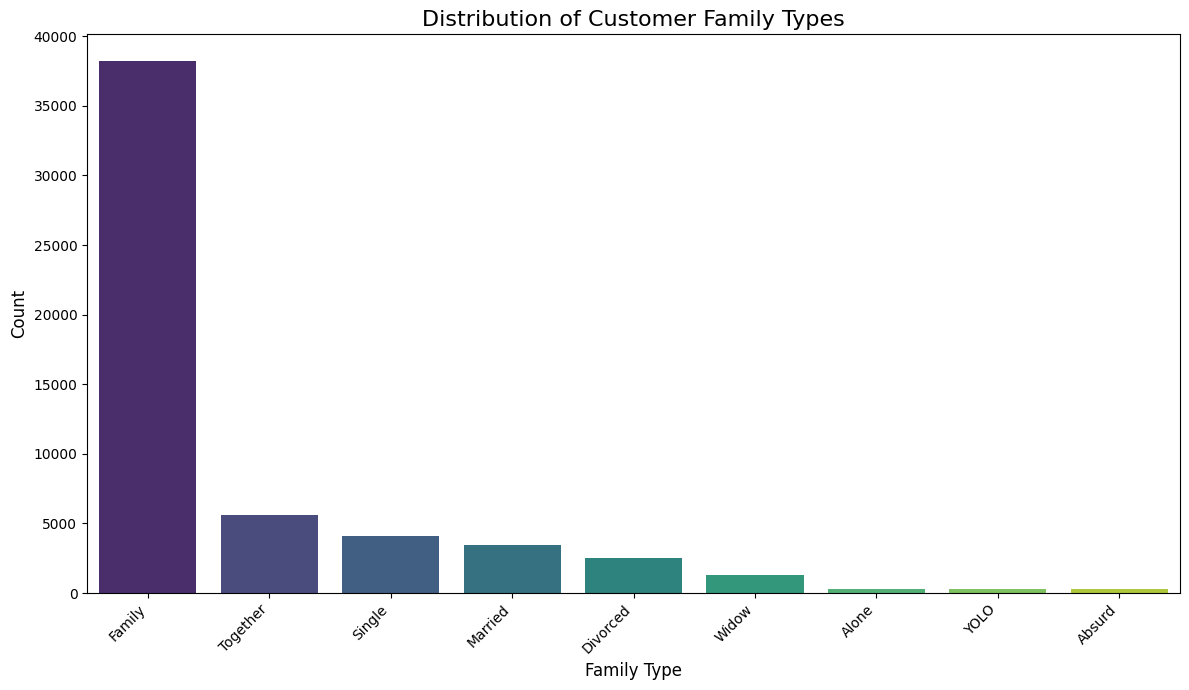

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for Family Type distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='Family Type', y='Count', data=family_type_counts, palette='viridis', hue='Family Type', legend=False)
plt.title('Distribution of Customer Family Types', fontsize=16)
plt.xlabel('Family Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Distribution by Country**

Total counts for each Country:
+----+--------------+---------+
|    | Country      |   Count |
+====+==============+=========+
|  0 | Spain        |   16703 |
+----+--------------+---------+
|  1 | Canada       |   10746 |
+----+--------------+---------+
|  2 | Saudi Arabia |    8422 |
+----+--------------+---------+
|  3 | Australia    |    5677 |
+----+--------------+---------+
|  4 | India        |    4814 |
+----+--------------+---------+
|  5 | Germany      |    4432 |
+----+--------------+---------+
|  6 | USA          |    4331 |
+----+--------------+---------+
|  7 | Mexico       |     875 |
+----+--------------+---------+


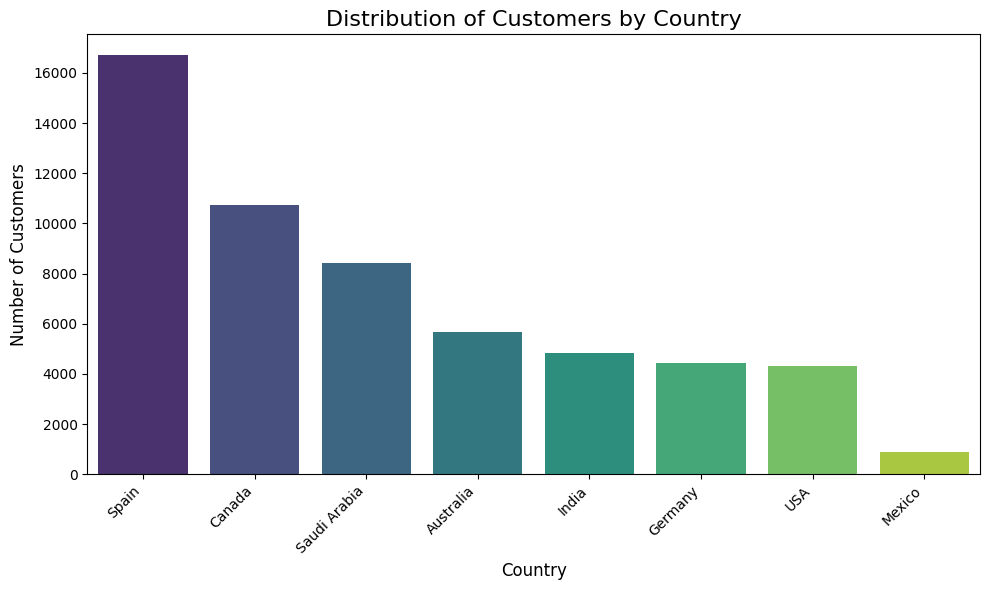

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('marketing_data.db')

sql_query = "SELECT Country FROM marketing_data"

country_distribution_df = pd.read_sql_query(sql_query, conn);

country_counts = country_distribution_df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
conn.close()

print('Total counts for each Country:')
print(tabulate(country_counts, headers='keys', tablefmt='grid'))

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Count', data=country_counts, palette='viridis', hue='Country', legend=False)
plt.title('Distribution of Customers by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()